In [22]:
!pip install opencv-python
!pip install seaborn scikit-learn pandas

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import confusion_matrix


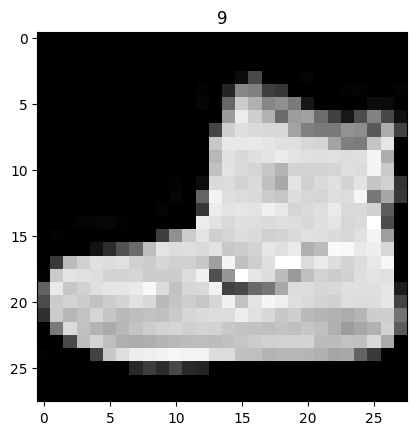

In [6]:
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True
)

image, label = train_dataset[0]

plt.imshow(image, cmap='gray')
plt.title(label)
plt.show()


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST( root='./data',train=True,download=True,transform=transform)

test_dataset = torchvision.datasets.FashionMNIST(root='./data',train=False,download=True,transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

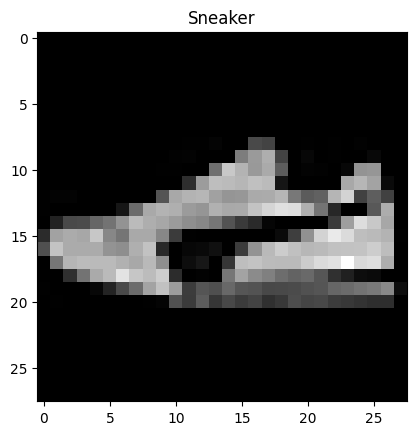

In [8]:
classes = ['T-shirt','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle Boot']

dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(classes[labels[0]])
plt.show()

In [9]:
class FashionCNN(nn.Module):

    def __init__(self):
        super(FashionCNN,self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Linear(128*3*3,128),
            nn.ReLU(),
            nn.Linear(128,10)

        )

    def forward(self,x):

        x = self.conv(x)

        x = x.view(x.size(0),-1)

        x = self.fc(x)

        return x


model = FashionCNN()

print(model)

FashionCNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=1152, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
epochs = 5

train_losses = []

for epoch in range(epochs):
    running_loss = 0
    for images,labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss)

    print("Epoch:",epoch+1,"Loss:",running_loss)

Epoch: 1 Loss: 436.5522068142891
Epoch: 2 Loss: 264.45469142124057
Epoch: 3 Loss: 224.87941648811102
Epoch: 4 Loss: 197.42382545396686
Epoch: 5 Loss: 173.8728300780058


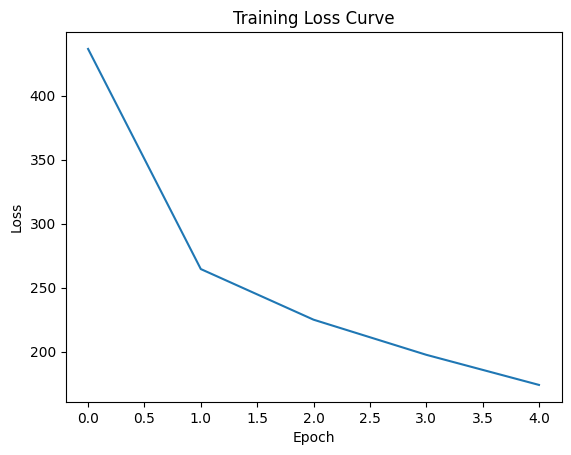

In [12]:
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [13]:
correct = 0
total = 0

with torch.no_grad():
    for images,labels in test_loader:
        outputs = model(images)
        _,predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted==labels).sum().item()

accuracy = 100*correct/total

print("Test Accuracy:",accuracy)

Test Accuracy: 91.05


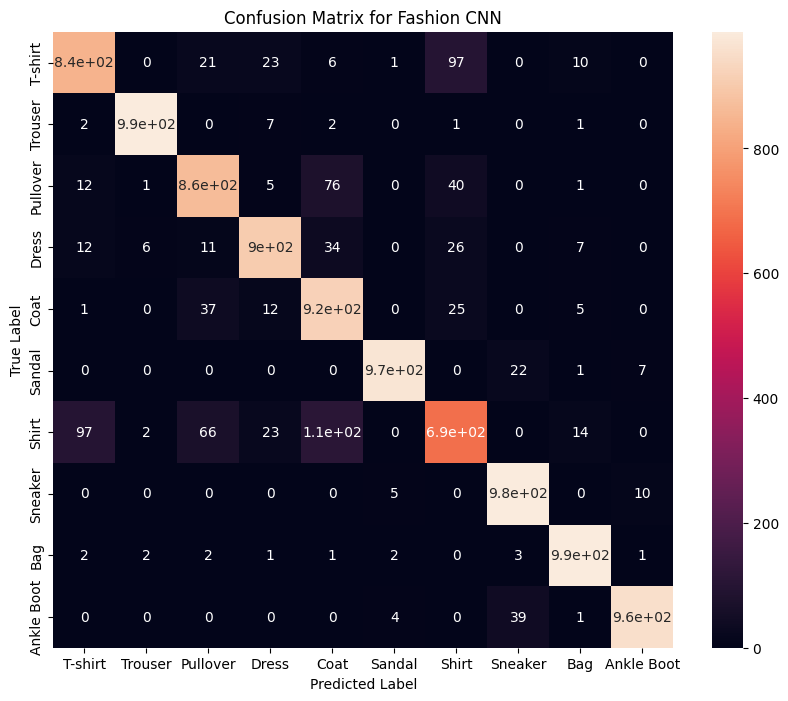

In [16]:
all_preds = []
all_labels = []
with torch.no_grad():
    for images,labels in test_loader:
        outputs = model(images)
        _,predicted = torch.max(outputs,1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())
classes = ['T-shirt','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle Boot']

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Fashion CNN")

plt.show()

In [17]:
dataiter = iter(test_loader)
images,labels = next(dataiter)

outputs = model(images)

probabilities = torch.softmax(outputs, dim=1)

_,predicted = torch.max(outputs,1)

confidence = torch.max(probabilities,1).values

True: Ankle Boot
Predicted: Ankle Boot
Confidence: 0.9992638230323792


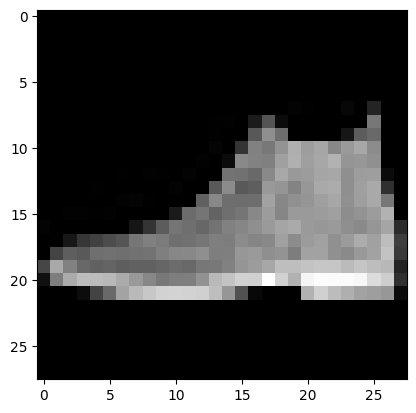

True: Pullover
Predicted: Pullover
Confidence: 0.9993115663528442


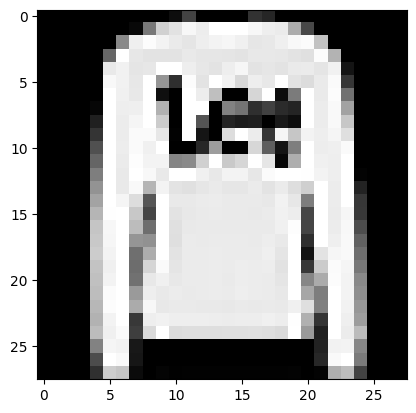

True: Trouser
Predicted: Trouser
Confidence: 1.0


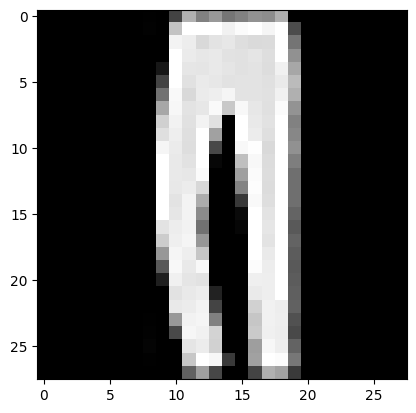

True: Trouser
Predicted: Trouser
Confidence: 1.0


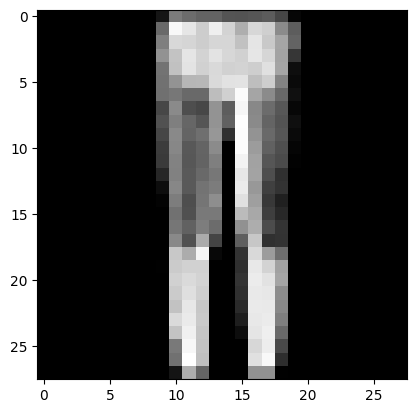

True: Shirt
Predicted: Shirt
Confidence: 0.9700130820274353


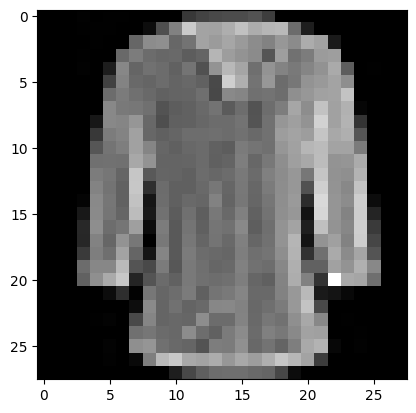

In [18]:
for i in range(5):

    plt.imshow(images[i].squeeze(), cmap='gray')
    print("True:",classes[labels[i]])
    print("Predicted:",classes[predicted[i]])
    print("Confidence:",confidence[i].item())
    plt.show()

In [19]:
torch.save(model.state_dict(),"fashion_cnn_model.pth")

In [20]:
from google.colab import files
files.download("fashion_cnn_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
misclassified = []

with torch.no_grad():
    for images,labels in test_loader:
        outputs = model(images)
        _,predicted = torch.max(outputs,1)
        for i in range(len(predicted)):
            if predicted[i] != labels[i]:
                misclassified.append((images[i], predicted[i], labels[i]))
            if len(misclassified) >= 5:
                break

True: Coat
Predicted: Shirt


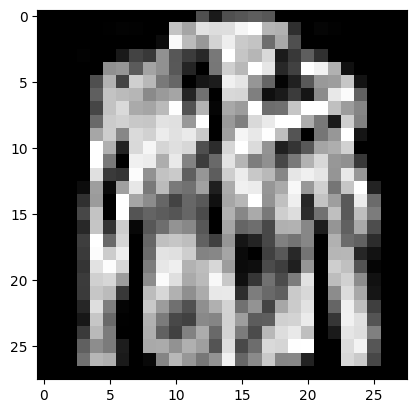

True: Ankle Boot
Predicted: Sandal


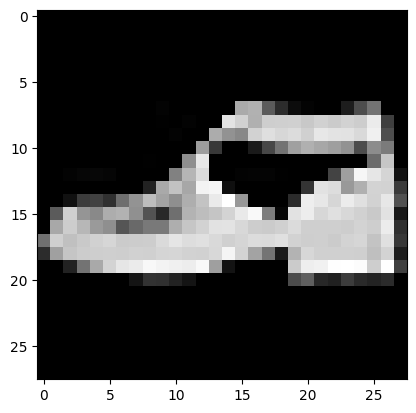

True: Dress
Predicted: Bag


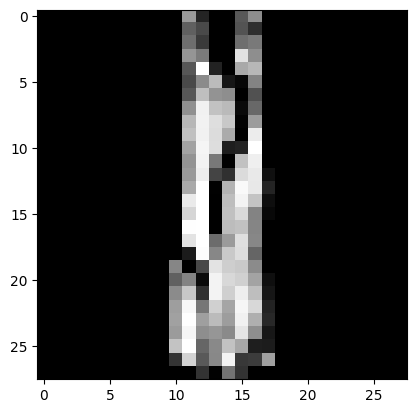

True: Shirt
Predicted: T-shirt


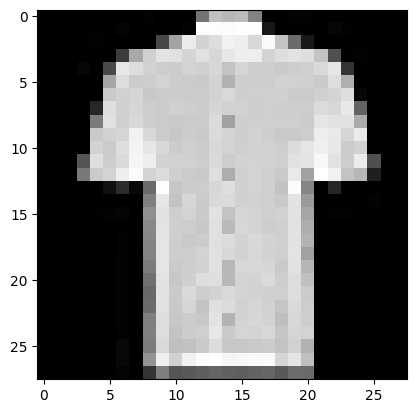

True: Dress
Predicted: Shirt


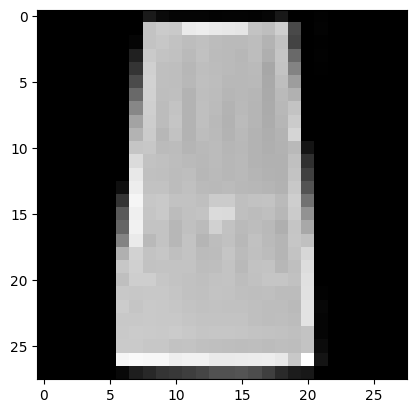

True: Dress
Predicted: Bag


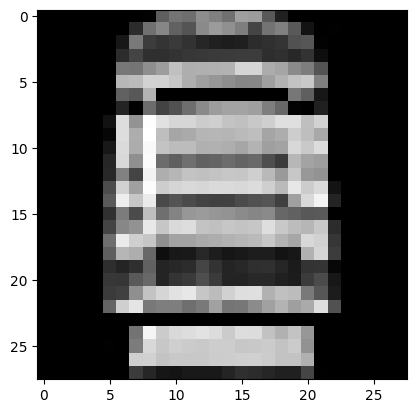

True: Pullover
Predicted: Coat


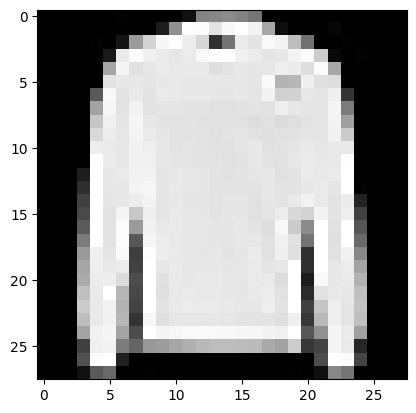

True: Coat
Predicted: Shirt


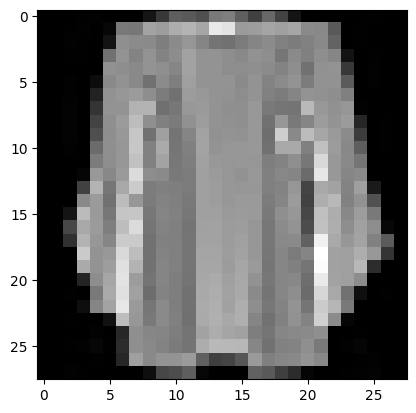

True: Bag
Predicted: T-shirt


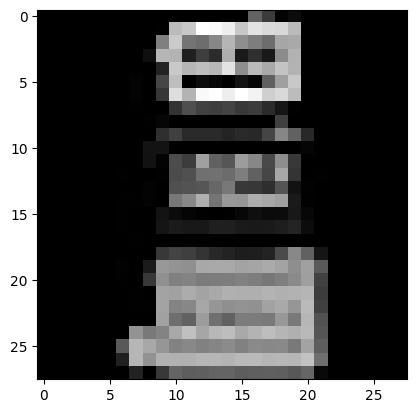

True: T-shirt
Predicted: Dress


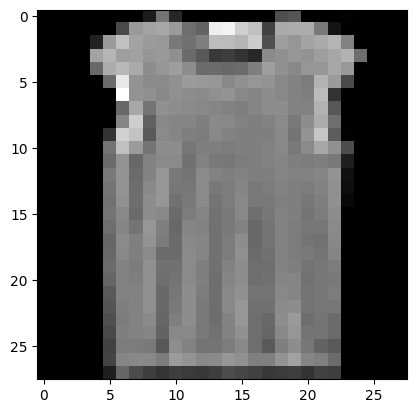

True: Coat
Predicted: Shirt


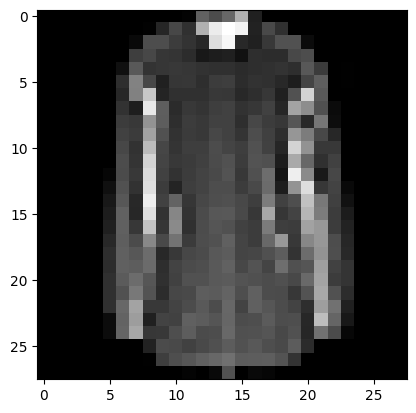

True: Shirt
Predicted: Pullover


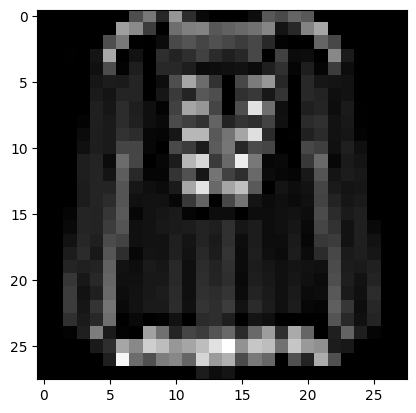

True: Sandal
Predicted: Sneaker


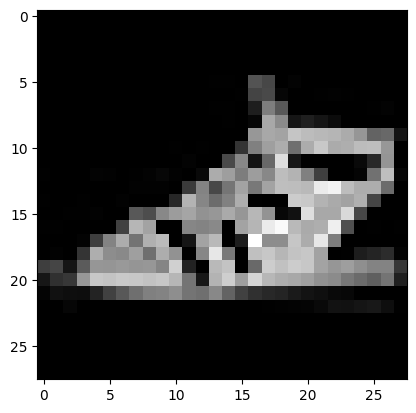

True: Shirt
Predicted: Pullover


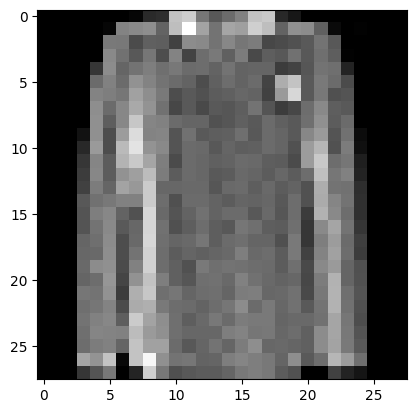

True: Shirt
Predicted: Dress


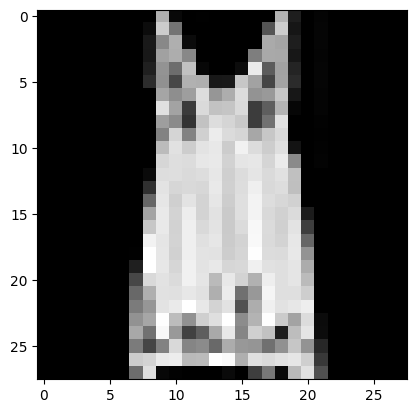

True: Shirt
Predicted: T-shirt


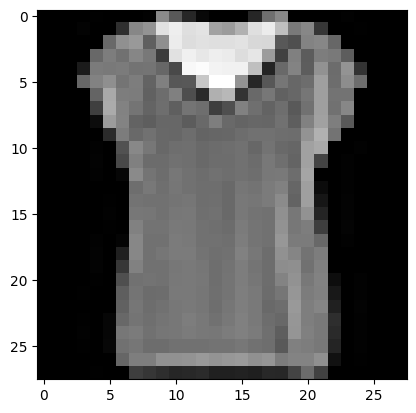

True: Pullover
Predicted: Coat


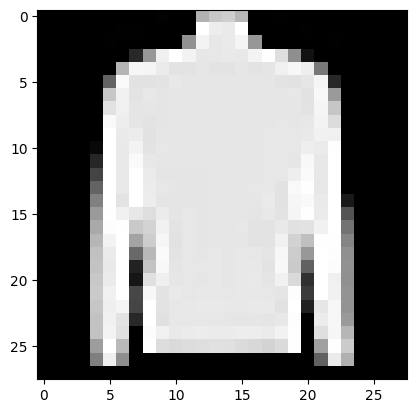

True: Coat
Predicted: Dress


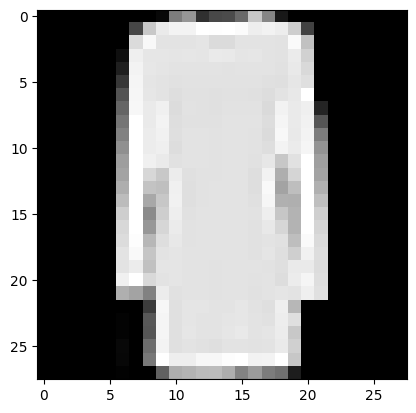

True: Shirt
Predicted: Coat


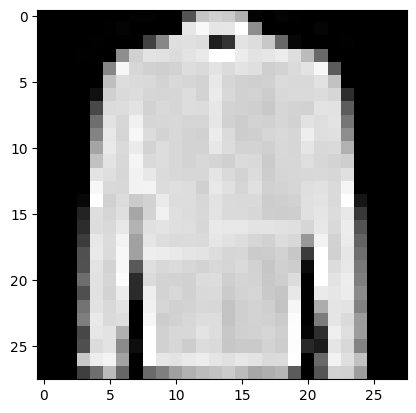

True: Coat
Predicted: Pullover


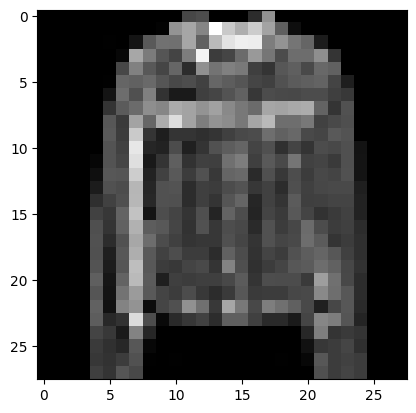

True: Ankle Boot
Predicted: Sneaker


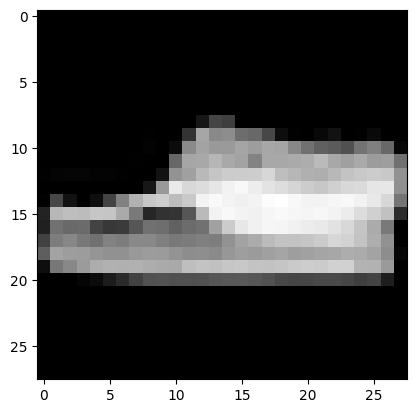

True: T-shirt
Predicted: Shirt


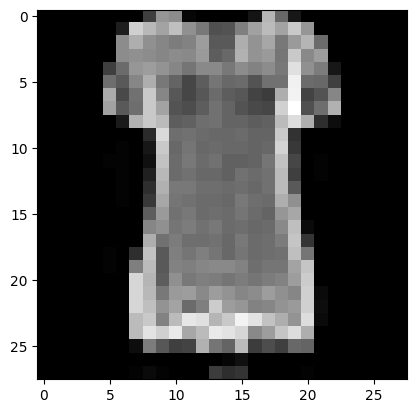

True: Pullover
Predicted: Coat


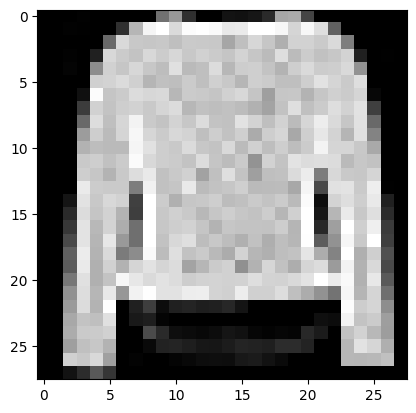

True: T-shirt
Predicted: Shirt


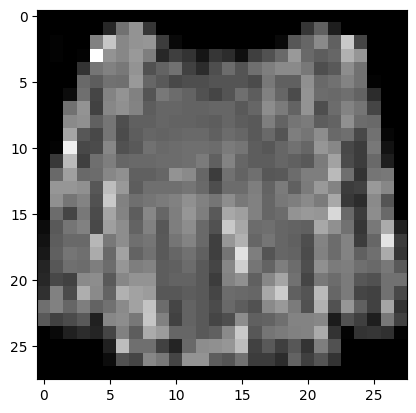

In [22]:
for img,pred,true in misclassified:

    plt.imshow(img.squeeze(), cmap='gray')

    print("True:",classes[true])
    print("Predicted:",classes[pred])

    plt.show()

In [24]:
learning_rates = [0.01, 0.001, 0.0005]

results = {}

for lr in learning_rates:

    model = FashionCNN()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(3):

        for images,labels in train_loader:

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in test_loader:

            outputs = model(images)

            _,predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    acc = 100*correct/total

    results[lr] = acc

print(results)

{0.01: 84.93, 0.001: 90.09, 0.0005: 89.47}
